# Latent Space Robustness

In this notebook, we explore the different metrics we can measure to analyze embedding space alignment, meaning how close are two representations produced by different neural networks.

In [1]:
import sys
sys.path.append('../../')
import json
import transformers
from polygene.model.model import Polygene, load_trained_model
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

model_config = transformers.AutoConfig.from_pretrained("../model/polygene_architecture_seeds.json")

model_config.vocab_size = int(12e2)
model_config.type_vocab_size = int(5e4)
model_config.pad_token_id = 2
model_config.classification_token = True

model_config.obs_included_phenotypes = ['disease', 'tissue', 'cell_type', 'sex', 'development_stage', 'assay',]
model_config.phenotypic_tokens_map = json.load(open("../data_utils/vocab/cxg_phenotypic_tokens_map.json"))
model_config.n_bins = 10
model = Polygene._from_config(model_config)

def num_params(module):
    total = sum(p.numel() for p in module.parameters())
    print(next((f"{total/t:.3f}{u}" for t,u in [(1e6,"M"),(1e3,"K")] if total>=t), total))

num_params(model)

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


27.189M


In [ ]:
import numpy as np
import scanpy as sc
from polygene.eval.metrics import prepare_cell, test_batch
from polygene.data_utils.data_collators import collate_fn_wrapper
from tqdm import tqdm
cell_data = sc.read_h5ad('/media/rohola/ssd_storage/primary/cxg_chunk2502.h5ad')
temperature = 1e-2
phene = 1
X = []
SEEDS_EXPERIMENT_PATH = '/media/lleger/LaCie/seeds_experiment/'
for path in [SEEDS_EXPERIMENT_PATH + f"polygene_{idx}/" for idx in [0, 1, 2]]+ [SEEDS_EXPERIMENT_PATH + "../POLYGENE/"]:
    model, tokenizer = load_trained_model(path, checkpoint_n=3)
    tokenizer.bypass_inference = True

    output_representations = []
    for cell in tqdm(cell_data[:5000], path):
        prepared_cell = prepare_cell(cell, tokenizer)
        prepared_cell["labels"] = prepared_cell['input_ids'].detach().clone()
        prepared_cell["input_ids"][phene:phene+len(tokenizer.phenotypic_types)] = tokenizer.convert_tokens_to_ids(tokenizer.mask_token)
        del prepared_cell['str_labels']
        output = test_batch([prepared_cell], model, collate_fn_wrapper(tokenizer))
        output_representations.append(output.hidden_states[:, 0].detach().cpu().numpy())
    X.append(np.concatenate(output_representations))

/media/lleger/LaCie/seeds_experiment/polygene_2/: 100%|██████████| 5000/5000 [02:02<00:00, 40.94it/s]
/media/lleger/LaCie/seeds_experiment/../POLYGENE/: 100%|██████████| 5000/5000 [02:39<00:00, 31.32it/s]


In [79]:
pd.to_pickle(X, SEEDS_EXPERIMENT_PATH + 'representations.pkl')

In [153]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cross_decomposition import CCA
from sklearn.metrics import pairwise_distances
from scipy.spatial import procrustes

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y,):
    k = int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

X = pd.read_pickle(SEEDS_EXPERIMENT_PATH + "representations.pkl")[:-1]

print('Learned representations shape', [mat.shape for mat in X])
import itertools
procrustes_wrap = lambda x,y: 1 - procrustes(x,y)[2]

# We also tried procrustes and SVCCA but they don't accept harsher hypothesis perturbations. AKA Different matrix sizes dim=1 in X and Y
scores = []
for idx, (x_mat, y_mat) in enumerate(itertools.combinations(X, r=2)):
    s = []
    print("Combinations:\n", idx)
    #for n, func in zip([ 'Mutual kNN'], [ mutual_knn]):
    for n, func in zip(['CKA', 'Mutual kNN'], [cka_linear, mutual_knn]):
        value = func(x_mat, y_mat)
        print(n, round(func(x_mat, y_mat), 4))
        if n in ['CKA', 'Mutual kNN']: s.append(value)
    scores.append(s)

Learned representations shape [(5000, 256), (5000, 256), (5000, 256)]
Combinations:
 0
CKA 0.8917
Mutual kNN 0.773
Combinations:
 1
CKA 0.8881
Mutual kNN 0.768
Combinations:
 2
CKA 0.8904
Mutual kNN 0.775


In [163]:
random_matrices = [np.random.uniform(size=X[0].shape) for _ in range(2)]
random_cka = cka_linear(random_matrices[0], random_matrices[1])
random_mknn = mutual_knn(random_matrices[0], random_matrices[1], )
baseline_performance = (2*random_cka*random_mknn)/(random_cka+random_mknn)
baseline_performance=random_cka

print(baseline_performance, random_cka, random_mknn)

0.048633811706763674 0.048633811706763674 0.0103


[0.8280934245688908, 0.8236782065427379, 0.8286954591403544]


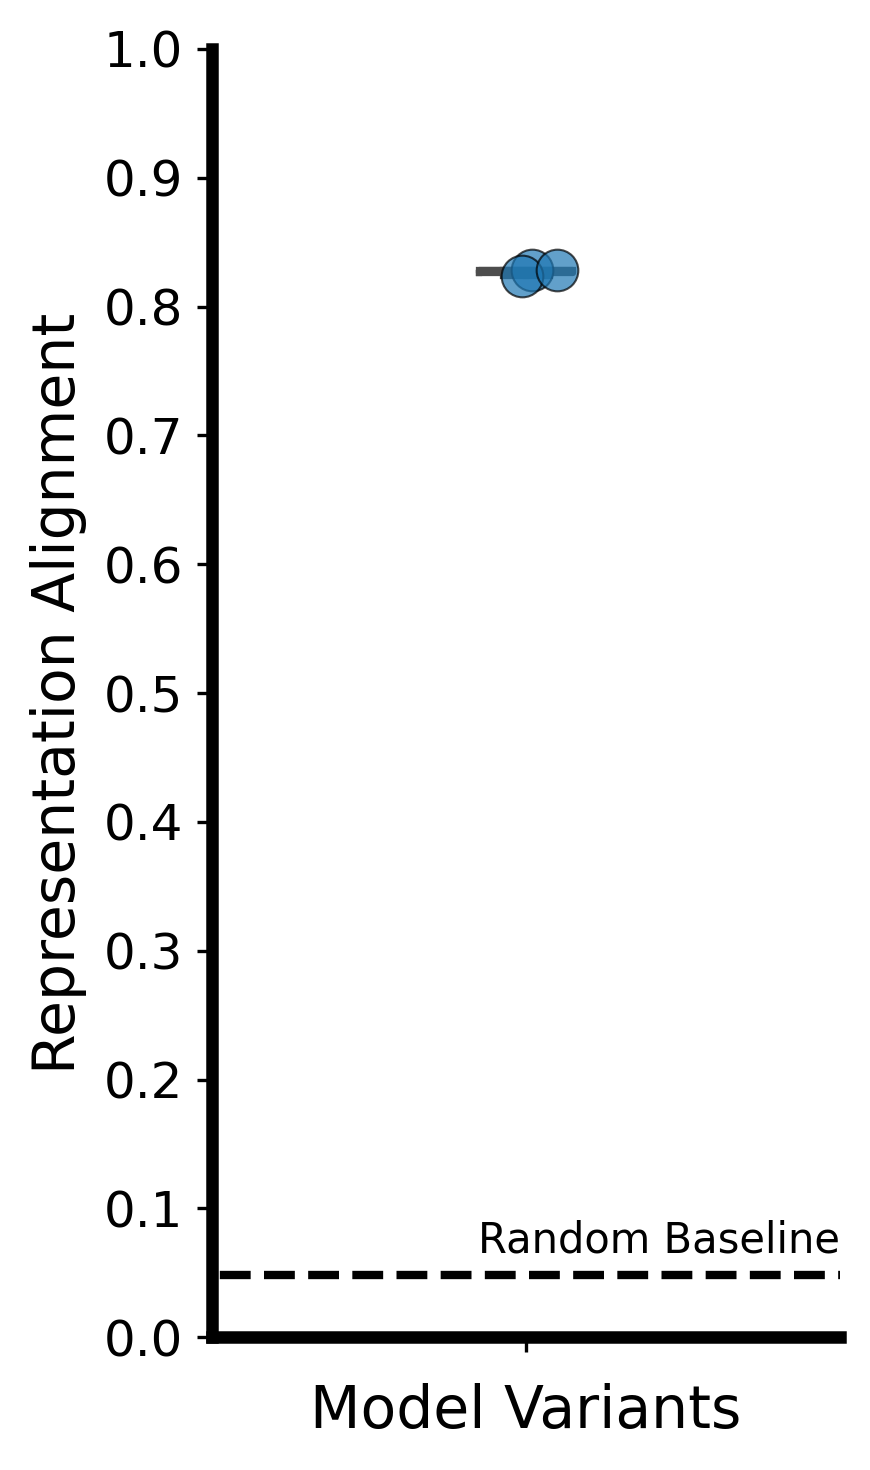

In [166]:
SAVE = True
SAVE_PATH = "dvec_figures/figure2/"

fig,ax = plt.subplots(1,1, figsize=(3,5), dpi=300 if SAVE else 100)
fontsize=12
colors = sns.color_palette('Paired', 2)
harmonic_means = [s[0] for s in scores]
harmonic_means = [(2*s[0]*s[1])/(s[0] + s[1]) for s in scores]
print(harmonic_means)
np.random.seed(5)
ax.scatter(np.array([0]*len(harmonic_means)) + np.random.randn(len(harmonic_means))*0.02,
 harmonic_means, color=colors[1], s=100, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.boxplot(harmonic_means)
box_color = (.30, .30, .30)
median_color = (.30, .30, .30)
box_linewidth = 1.5
bp = ax.boxplot(x=np.array(harmonic_means),positions=[0], showfliers=False,zorder=-3, boxprops=dict(color=box_color, linewidth=box_linewidth),
                whiskerprops=dict(color=box_color, linewidth=box_linewidth),
                capprops=dict(color=box_color, linewidth=box_linewidth),
                medianprops=dict(color=median_color, linewidth=box_linewidth, zorder=-4),)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, 1)
ax.set_xticks([0], [""], fontsize=fontsize)
ax.set_yticks(np.linspace(0, 1, num=11), fontsize=fontsize)
ax.tick_params(axis='both', labelsize=fontsize)
ax.set_xlabel('Model Variants', fontsize=fontsize + 2)
ax.set_ylabel('Representation Alignment', fontsize=fontsize + 2)
ax.spines[['top', 'right']].set_linewidth(0)
ax.hlines(y=baseline_performance, xmin=-1, xmax=1, linestyles='--', color='k', lw=2)
ax.text(0.5, baseline_performance+0.01, "Random Baseline", 
        ha='right', va='bottom', fontsize=fontsize-2)
ax.spines[['bottom', 'left']].set_linewidth(3)
#ax.spines[['bottom', 'left']].set_color('0.8')
plt.tight_layout()
if SAVE:
    plt.savefig(SAVE_PATH + 'representation_alignment.png', transparent=True, dpi=300)
    plt.savefig(SAVE_PATH + 'representation_alignment.svg', transparent=True, dpi=300)
plt.show()

In [19]:
from scipy.spatial import procrustes
import numpy as np
from tqdm import tqdm

def combined_metric(X, Y):
    cka = cka_linear(X, Y)
    mknn = mutual_knn(X, Y, k=int(0.01*len(X)))
    if mknn > 0 and cka > 0:
        return 2 * (cka * mknn) / (cka + mknn)
    else:
        return 0.0

def baseline_test(X, Y, repeats=1000, rng=None):
    rng = np.random.default_rng(rng)
    obs = combined_metric(X, Y)
    null_scores = []
    for _ in tqdm(range(repeats)):
        Y_perm = Y[rng.permutation(Y.shape[0])]
        null_scores.append(combined_metric(X, Y_perm))
    
    null_scores = np.array(null_scores)
    z = (obs - null_scores.mean()) / null_scores.std()
    return obs, z, null_scores, null_scores.mean(), null_scores.std()

obs, z, null, mean_null, std_null = baseline_test(X[0], X[1])
print("Observed:", obs)
print("Null mean:", mean_null)
print("Null std:", std_null)
print("Z-score:", z)
print("p_value:", (np.sum(null >= obs) + 1) / (len(null) + 1))

100%|██████████| 1000/1000 [03:07<00:00,  5.32it/s]

Observed: 0.8235375078952227
Null mean: 0.01641797628381226
Null std: 0.0015823927421290019
Z-score: 510.06271080685445
p_value: 0.000999000999000999
